In [9]:
import pandas as pd
import torch
from rdkit import Chem
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

print(torch.__version__)

2.10.0


In [10]:
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

In [11]:
data = pd.read_csv("../Dataset/qm8.csv")

In [12]:
data = data.iloc[:100,:]

In [13]:
def smiles_to_graph(smiles, y_labels=None):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    
    # Add hydrogens explicitly as they are often important in QM datasets
    mol = Chem.AddHs(mol)
    
    # Atom features: Atomic number
    atom_features = []
    for atom in mol.GetAtoms():
        atom_features.append([atom.GetAtomicNum()])
    x = torch.tensor(atom_features, dtype=torch.float)
    
    # Edge index: Bonds
    edge_index = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_index.append([i, j])
        edge_index.append([j, i])
    
    if not edge_index:
        edge_index = torch.empty((2, 0), dtype=torch.long)
    else:
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

    y = None
    if y_labels is not None:
        y = torch.tensor([y_labels], dtype=torch.float)
    
    return Data(x=x, edge_index=edge_index)

data['graph'] = data['smiles'].apply(smiles_to_graph)

In [25]:
data.graph.head()

0    [(x, [tensor([6.]), tensor([1.]), tensor([1.])...
1    [(x, [tensor([7.]), tensor([1.]), tensor([1.])...
2    [(x, [tensor([8.]), tensor([1.]), tensor([1.])...
3    [(x, [tensor([6.]), tensor([6.]), tensor([1.])...
4    [(x, [tensor([6.]), tensor([7.]), tensor([1.])...
Name: graph, dtype: object

In [15]:
data.graph[1]

Data(x=[4, 1], edge_index=[2, 6])

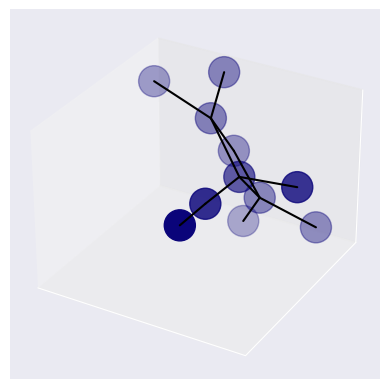

In [23]:
G = to_networkx(data['graph'][95], to_undirected=True)

pos = nx.spring_layout(G, dim=3, seed=0)

node_xyz = np.array([pos[v] for v in sorted(G)])
edge_xyz = np.array([(pos[v], pos[u]) for u, v in G.edges()])

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for dim in (ax.xaxis, ax.yaxis, ax.zaxis):
    dim.set_ticks([])

ax.scatter(*node_xyz.T, s=500, c='#0A047A')

for vizedge in edge_xyz:
    ax.plot(*vizedge.T, color='k')

plt.show()

In [24]:
from torch.nn import Linear, ReLU, Sequential, BatchNorm1d, Dropout
import torch.nn.functional as F
from torch_geometric.nn import GINConv
from torch_geometric.nn import global_add_pool, global_mean_pool

In [ ]:
from typing import Any


class GIN(torch.nn.Module):
    """
    This class is an implementation of Graph Isomorphism Network (GIN) for graph-level regression tasks. The GIN architecture is designed to capture the structural information of graphs effectively, making it suitable for tasks like molecular property prediction.
    """
    def __init__(self, dim_h, dataset: Any):
        super(GIN, self).__init__()
        self.conv1 = GINConv(
            Sequential(Linear(dataset.num_node_features, dim_h),
                       BatchNorm1d(dim_h), ReLU(),
                       Linear(dim_h, dim_h), ReLU())
        )
        self.conv2 = GINConv(
            Sequential(Linear(dim_h, dim_h), BatchNorm1d(dim_h), ReLU(),
                       Linear(dim_h, dim_h), ReLU())
        )
        self.conv3 = GINConv(
            Sequential(Linear(dim_h, dim_h), BatchNorm1d(dim_h), ReLU(),
                       Linear(dim_h, dim_h), ReLU())
        )
        self.MLP = Sequential(
            Linear(dim_h, dim_h), ReLU(),
            Linear(dim_h, 12), ReLU(),
        )

    def forward(self, x, edge_index, batch):
        # Node embeddings
        h1 = self.conv1(x, edge_index)
        h2 = self.conv2(h1, edge_index)
        h3 = self.conv3(h2, edge_index)

        # Graph-level readout (concatenation of global mean and sum pooling)
        h1 = global_add_pool(h1, batch)
        h2 = global_add_pool(h2, batch)
        h3 = global_add_pool(h3, batch)

